# Infra-Bench FM Evaluation: SatlasPretrain on Multi-Sector Critical Infrastructure (v1)

**Purpose:** Linear-probe smoke test of SatlasPretrain across 13 critical-infrastructure classes spanning 4 sectors (energy, water, transport, telecom). Validates that the harness generalizes beyond substations and produces honest per-class / per-sector / per-region numbers.

**Design choices (v1):**
- **13-class classification** spanning energy generation/transmission/distribution, water storage/treatment/wastewater, transport airports/stations/ports, and telecom data centers.
- **Multi-sector v1 datasets only:** folders matching `^dataset_<region>_(energy|water|transport|telecom)_v1$`. Substation-only `*_stac_v1` and `*_minimal_v1` folders are ignored.
- **Sentinel-2 multispectral only** (bands 0-6); S1 fusion deferred.
- **Linear probe only** for this smoke test. No fine-tune. Class-weighted CrossEntropy handles imbalance (no oversampling / focal loss).
- **Resize to 224x224**; native tiles are ~61x61.
- **Three reporting levels:** per-class F1 (13), per-sector F1 (4), per-region F1 (4).
- **Uses existing codebase modules** (`NpyInfrastructureDataset`, `io.percentile_normalize`) — inputs match the SimCLR pretraining baseline byte-for-byte.


## 1. Mount Drive + check GPU


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch
print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU. Go to Runtime -> Change runtime type -> GPU.')


Mounted at /content/drive
GPU available: False


In [2]:
# Silence the per-band warning that fires once per worker process for every tile load.
# We're intentionally using 7 of 9 bands (S2 only, S1 deferred to v2); the warning is noise.
import warnings
warnings.filterwarnings('ignore', message='Tile has .* bands but band_indices')

## 2. Install dependencies


In [3]:
%%capture
!pip install satlaspretrain-models scikit-learn


## 3. Extract codebase from Drive

Same pattern as `infra_fm_multicontinent_pretrain.ipynb`. The zip lives at `<DRIVE_ROOT>/code/infra_fm_curation.zip` and contains `infra_fm_code_only/{curation,downstream,pretraining,...}`. Putting it on `sys.path` lets us import the canonical `NpyInfrastructureDataset` (which uses your `io.percentile_normalize`, your band parsing, etc.) so this notebook's inputs match the SimCLR pretraining inputs byte-for-byte.


In [4]:
import os, sys, zipfile
from pathlib import Path

DRIVE_ROOT = '/content/drive/MyDrive/infra_fm'
CODE_ZIP   = f'{DRIVE_ROOT}/code/infra_fm_curation.zip'
EXTRACT_TO = '/content/infra_fm_clean'
CODE_ROOT  = f'{EXTRACT_TO}/infra_fm_code_only'

if not Path(f'{CODE_ROOT}/downstream').exists():
    print('Extracting code...')
    os.makedirs(EXTRACT_TO, exist_ok=True)
    with zipfile.ZipFile(CODE_ZIP, 'r') as z:
        for member in z.namelist():
            clean_path = member.replace('\\', '/')
            target = os.path.join(EXTRACT_TO, clean_path)
            if clean_path.endswith('/'):
                os.makedirs(target, exist_ok=True)
            else:
                os.makedirs(os.path.dirname(target), exist_ok=True)
                with z.open(member) as src, open(target, 'wb') as dst:
                    dst.write(src.read())
    print('Done.')
else:
    print('Already extracted.')

sys.path.insert(0, CODE_ROOT)
os.chdir(CODE_ROOT)

# Import the canonical dataset class + helpers.
from downstream.common.comm_datasets import NpyInfrastructureDataset
from downstream.common.utils import set_seed
print('Imports OK')


Extracting code...
Done.
Imports OK


## 4. Configuration


In [5]:
import json

DATASETS_DRIVE = f'{DRIVE_ROOT}/datasets'        # where the .zip data files live on Drive
DATASETS_LOCAL = '/content/datasets'             # extracted destination, fast local disk
OUTPUT_DIR     = f'{DRIVE_ROOT}/results/fm_eval_satlas_multisector_v1'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DATASETS_LOCAL, exist_ok=True)

# All 7 continents per Geofabrik. Discovery logic below skips empty / missing
# folders gracefully — safe to leave a region in this list even if its zip
# isn't on Drive yet.
REGIONS = [
    'africa',
    'asia',
    'australia-oceania',
    'central-america',
    'europe',
    'north-america',
    'south-america',
]
SECTORS = ['energy', 'water', 'transport', 'telecom']
SECTOR_TO_IDX = {s: i for i, s in enumerate(SECTORS)}

# 13-class taxonomy (LOCKED for v1).
CLASS_NAMES = [
    'energy.transmission.substation',
    'energy.distribution.substation',
    'energy.distribution.other',          # pools substation_untyped + substation_minor
    'energy.generation.power_plant',
    'energy.generation.solar_farm',
    'energy.generation.wind_farm',
    'water.wastewater.plant',
    'water.treatment.plant',
    'water.storage_tank',
    'transport.airport',
    'transport.train_station',
    'transport.port_terminal',
    'telecom.data_center',
]
CLASS_TO_IDX = {n: i for i, n in enumerate(CLASS_NAMES)}

# Sector for each class index (derived from class name prefix).
CLASS_IDX_TO_SECTOR = {i: name.split('.')[0] for i, name in enumerate(CLASS_NAMES)}

# Raw asset_type (from manifests) -> canonical class name.
ASSET_TYPE_MAP = {
    'energy.transmission.substation':         'energy.transmission.substation',
    'energy.distribution.substation':         'energy.distribution.substation',
    'energy.distribution.substation_untyped': 'energy.distribution.other',
    'energy.distribution.substation_minor':   'energy.distribution.other',
    'energy.generation.power_plant':          'energy.generation.power_plant',
    'energy.generation.solar_farm':           'energy.generation.solar_farm',
    'energy.generation.wind_farm':            'energy.generation.wind_farm',
    'water.wastewater.plant':                 'water.wastewater.plant',
    'water.treatment.plant':                  'water.treatment.plant',
    'water.storage_tank':                     'water.storage_tank',
    'transport.airport':                      'transport.airport',
    'transport.train_station':                'transport.train_station',
    'transport.port_terminal':                'transport.port_terminal',
    'telecom.data_center':                    'telecom.data_center',
}

# Training config.
BAND_INDICES = '0,1,2,3,4,5,6'   # Sentinel-2 multispectral only; S1 (7,8) deferred to v2
IMAGE_SIZE   = 224                # SatlasPretrain-friendly; resized from native ~61x61
SEED         = 42

# ---- LINEAR PROBE SMOKE TEST CONFIG ----
# Linear probe only for v1. Class-weighted CE handles imbalance — no oversampling / focal loss.
LP_EPOCHS, LP_BATCH, LP_LR = 25, 16, 1e-3

set_seed(SEED)
print(f'Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}')
print(f'Sectors:                     {SECTORS}')
print(f'Regions:                     {REGIONS}')
print(f'Bands:                       {BAND_INDICES}')
print(f'Output dir:                  {OUTPUT_DIR}')
print(f'[Linear probe smoke test]    {LP_EPOCHS} epochs, batch {LP_BATCH}, lr {LP_LR}')

Classes (13): ['energy.transmission.substation', 'energy.distribution.substation', 'energy.distribution.other', 'energy.generation.power_plant', 'energy.generation.solar_farm', 'energy.generation.wind_farm', 'water.wastewater.plant', 'water.treatment.plant', 'water.storage_tank', 'transport.airport', 'transport.train_station', 'transport.port_terminal', 'telecom.data_center']
Sectors:                     ['energy', 'water', 'transport', 'telecom']
Regions:                     ['africa', 'asia', 'australia-oceania', 'central-america', 'europe', 'north-america', 'south-america']
Bands:                       0,1,2,3,4,5,6
Output dir:                  /content/drive/MyDrive/infra_fm/results/fm_eval_satlas_multisector_v1
[Linear probe smoke test]    25 epochs, batch 16, lr 0.001


## 5. Discover + extract multi-sector v1 datasets

Data on Drive lives as one folder OR one zip per `(region, sector)` pair, matching the regex `^dataset_<region>_(energy|water|transport|telecom)_v1(\.zip)?$`. **Substation-only `*_stac_v1` and `*_minimal_v1` folders/zips are explicitly skipped.**

The cell below:
1. Lists what's actually on Drive so you can see filenames.
2. For each `(region, sector)` pair: extracts the zip (if present) to `/content/datasets/`, or uses the folder directly. Skips already-extracted / empty / missing.
3. Sanity-checks the layout: each extracted dataset should have `manifest.json` + `images/` with `.npy` tiles.


In [6]:
import zipfile, shutil, time, re
from pathlib import Path

# Show what's actually on Drive.
drive_path = Path(DATASETS_DRIVE)
print(f'Contents of {DATASETS_DRIVE}:')
if drive_path.exists():
    for entry in sorted(drive_path.iterdir()):
        if entry.suffix == '.zip':
            size_gb = entry.stat().st_size / 1e9
            print(f'  {entry.name:<55s} {size_gb:>6.2f} GB')
        elif entry.is_dir():
            print(f'  {entry.name}/  (dir)')
else:
    print('  (path does not exist)')
print()

# Regex: only multi-sector v1 datasets. Explicitly excludes *_stac_v1 and *_minimal_v1.
MULTISECTOR_RE = re.compile(r'^dataset_([a-z-]+)_(energy|water|transport|telecom)_v1_1k$')

def discover_multisector_sources():
    """Return list of (region, sector, source_path, is_zip) for every v1 multi-sector
    dataset present on Drive — folder or zip. Filtered by REGIONS."""
    sources = []
    seen = set()
    for entry in sorted(drive_path.iterdir()):
        stem = entry.stem if entry.suffix == '.zip' else entry.name
        m = MULTISECTOR_RE.match(stem)
        if not m:
            continue
        region, sector = m.group(1), m.group(2)
        if region not in REGIONS:
            continue
        key = (region, sector)
        if key in seen:
            continue
        seen.add(key)
        sources.append((region, sector, entry, entry.suffix == '.zip'))
    return sources


discovered = discover_multisector_sources()
print(f'Found {len(discovered)} multi-sector v1 sources matching REGIONS+SECTORS:')
for region, sector, path, is_zip in discovered:
    kind = 'zip' if is_zip else 'dir'
    print(f'  {region:<22s} {sector:<10s} [{kind}] {path.name}')

Contents of /content/drive/MyDrive/infra_fm/datasets:
  dataset_africa_energy_v1_1k.zip                           0.04 GB
  dataset_africa_stac_v1.zip                                0.18 GB
  dataset_africa_telecom_v1_1k.zip                          0.00 GB
  dataset_africa_transport_v1_1k.zip                        0.05 GB
  dataset_africa_water_v1_1k.zip                            0.04 GB
  dataset_asia_energy_v1_1k.zip                             0.04 GB
  dataset_asia_stac_v1.zip                                  0.76 GB
  dataset_asia_telecom_v1_1k.zip                            0.00 GB
  dataset_asia_transport_v1_1k.zip                          0.04 GB
  dataset_asia_water_v1_1k.zip                              0.05 GB
  dataset_australia-oceania_energy_v1_1k.zip                0.05 GB
  dataset_australia-oceania_stac_v1.zip                     0.11 GB
  dataset_australia-oceania_telecom_v1_1k (1).zip           0.00 GB
  dataset_australia-oceania_telecom_v1_1k.zip               0.

In [7]:
def materialize_source(region, sector, src_path, is_zip, force=False):
    """Make sure the dataset is available at /content/datasets/dataset_<region>_<sector>_v1_1k/
    with manifest.json + images/ inside. Returns the local Path or None on failure."""
    folder_name = f'dataset_{region}_{sector}_v1_1k'
    target_dir  = Path(DATASETS_LOCAL) / folder_name

    # Already extracted?
    if not force and (target_dir / 'manifest.json').exists():
        n = len(list((target_dir / 'images').glob('*.npy'))) if (target_dir / 'images').exists() else 0
        print(f'  [DONE]   {region:<22s} {sector:<10s} already present ({n} tiles)')
        return target_dir

    if not is_zip:
        # Source is a folder on Drive. Copy locally so /content/datasets has the same layout
        # regardless of whether source was zip or folder.
        if not (src_path / 'manifest.json').exists():
            print(f'  [EMPTY]  {region:<22s} {sector:<10s} no manifest.json in {src_path.name}')
            return None
        t0 = time.time()
        print(f'  [COPY]   {region:<22s} {sector:<10s} {src_path.name} -> {folder_name} ...',
              end=' ', flush=True)
        if target_dir.exists():
            shutil.rmtree(target_dir)
        shutil.copytree(src_path, target_dir)
        n = len(list((target_dir / 'images').glob('*.npy'))) if (target_dir / 'images').exists() else 0
        print(f'done in {time.time()-t0:.0f}s ({n} tiles)')
        return target_dir

    # Zip path.
    t0 = time.time()
    print(f'  [EXTRACT]{region:<22s} {sector:<10s} {src_path.name} -> {folder_name} ...',
          end=' ', flush=True)
    with zipfile.ZipFile(src_path) as zf:
        names = zf.namelist()
        wrapped_prefix = f'{folder_name}/'
        is_wrapped = any(n.startswith(wrapped_prefix) for n in names)
        if is_wrapped:
            zf.extractall(DATASETS_LOCAL)
        else:
            target_dir.mkdir(parents=True, exist_ok=True)
            zf.extractall(target_dir)
    n = len(list((target_dir / 'images').glob('*.npy'))) if (target_dir / 'images').exists() else 0
    print(f'done in {time.time()-t0:.0f}s ({n} tiles)')
    return target_dir


print('Materializing multi-sector datasets:')
ready = []  # list of (region, sector, local_path)
for region, sector, src_path, is_zip in discovered:
    local = materialize_source(region, sector, src_path, is_zip)
    if local is None:
        continue
    if (local / 'manifest.json').exists() and any((local / 'images').glob('*.npy')):
        ready.append((region, sector, local))

# Final readiness table.
print(f'\n{"region":<22s} {"sector":<10s} {"manifest":>10s} {"n_tiles":>10s}')
print('-' * 60)
for region, sector, local in ready:
    n = len(list((local / 'images').glob('*.npy')))
    print(f'{region:<22s} {sector:<10s} {"True":>10s} {n:>10d}')
print(f'\nReady (region, sector) pairs: {len(ready)} / {len(discovered)}')

Materializing multi-sector datasets:
  [EXTRACT]africa                 energy     dataset_africa_energy_v1_1k.zip -> dataset_africa_energy_v1_1k ... done in 3s (949 tiles)
  [EXTRACT]africa                 telecom    dataset_africa_telecom_v1_1k.zip -> dataset_africa_telecom_v1_1k ... done in 2s (1 tiles)
  [EXTRACT]africa                 transport  dataset_africa_transport_v1_1k.zip -> dataset_africa_transport_v1_1k ... done in 3s (1000 tiles)
  [EXTRACT]africa                 water      dataset_africa_water_v1_1k.zip -> dataset_africa_water_v1_1k ... done in 4s (892 tiles)
  [EXTRACT]asia                   energy     dataset_asia_energy_v1_1k.zip -> dataset_asia_energy_v1_1k ... done in 3s (889 tiles)
  [EXTRACT]asia                   telecom    dataset_asia_telecom_v1_1k.zip -> dataset_asia_telecom_v1_1k ... done in 2s (28 tiles)
  [EXTRACT]asia                   transport  dataset_asia_transport_v1_1k.zip -> dataset_asia_transport_v1_1k ... done in 3s (891 tiles)
  [EXTRACT]asia   

**Stop here if a sector/region pair you expect is missing above.** Common fixes:
- Wrong path: edit `DATASETS_DRIVE`.
- Folder/zip name doesn't match `^dataset_<region>_(energy|water|transport|telecom)_v1$`: rename.
- Region not in `REGIONS`: edit the list in section 4.

Africa energy is expected to be missing/empty for now (still being fetched). Notebook will proceed with whatever's ready.


## 6. Build datasets

Uses the canonical `NpyInfrastructureDataset` from `downstream.common.comm_datasets`. That class handles:
- Manifest parsing (the `{"records": [...]}` shape).
- Band selection (`band_indices='0,1,2,3,4,5,6'` = S2 MS only).
- Percentile normalization (matches `io.percentile_normalize`).
- HWC/CHW handling, min-size filtering, the works.

`MultiSectorLabelWrapper` adds, on top of the base dataset:
- `asset_type -> ASSET_TYPE_MAP -> CLASS_TO_IDX` integer-label mapping (13 classes).
- Resize to 224×224.
- `region` and `sector` attached to every sample for per-region / per-sector evaluation.

One wrapper is built per `(region, sector)` source. Final class distribution is printed across all sources combined — this is the table you should review before any training kicks off.


In [8]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from collections import Counter


class MultiSectorLabelWrapper(Dataset):
    """Adds label mapping + resize on top of NpyInfrastructureDataset.

    The base dataset returns:
        {'image': tensor(C, H, W), 'asset_type': str, 'asset_id': str, ...}

    This wrapper:
      - drops samples whose asset_type isn't in ASSET_TYPE_MAP
      - maps asset_type -> integer label in [0, len(CLASS_NAMES))
      - resizes (C, H, W) -> (C, IMAGE_SIZE, IMAGE_SIZE) via bilinear interpolation
      - attaches region + sector so per-region / per-sector evaluation works
    """
    def __init__(self, base_dataset, region, sector, input_size=IMAGE_SIZE):
        self.base = base_dataset
        self.region = region
        self.sector = sector
        self.input_size = input_size

        self.valid_indices = []
        self.labels = []
        for i, rec in enumerate(base_dataset.records):
            mapped = ASSET_TYPE_MAP.get(rec.asset_type)
            if mapped is None:
                continue
            self.valid_indices.append(i)
            self.labels.append(CLASS_TO_IDX[mapped])

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        base_idx = self.valid_indices[idx]
        sample = self.base[base_idx]
        img = sample['image']  # (C, H, W) float32, percentile-normalized
        img = F.interpolate(img.unsqueeze(0), size=(self.input_size, self.input_size),
                            mode='bilinear', align_corners=False).squeeze(0)
        return {
            'image':    img,
            'label':    self.labels[idx],
            'asset_id': sample.get('asset_id', ''),
            'region':   self.region,
            'sector':   self.sector,
        }


def build_source_dataset(region, sector, local_path):
    base = NpyInfrastructureDataset(
        dataset_root=str(local_path),
        band_indices=BAND_INDICES,
        require_labels=True,
        allowed_asset_types=list(ASSET_TYPE_MAP.keys()),
    )
    return MultiSectorLabelWrapper(base, region=region, sector=sector)


# Build one wrapper per (region, sector); collect side-by-side for class distribution.
source_datasets = {}  # (region, sector) -> dataset
for region, sector, local in ready:
    try:
        ds = build_source_dataset(region, sector, local)
    except Exception as e:
        print(f'  {region:<22s} {sector:<10s} FAILED: {e}')
        continue
    if len(ds) == 0:
        print(f'  {region:<22s} {sector:<10s} 0 valid samples (skipped)')
        continue
    source_datasets[(region, sector)] = ds
    counts = Counter(ds.labels)
    summary = ', '.join(f'{CLASS_NAMES[c]}={n}' for c, n in sorted(counts.items()))
    print(f'  {region:<22s} {sector:<10s} n={len(ds):>6d}  [{summary}]')

# Combined class distribution.
print('\n=== Combined class distribution (across all loaded sources) ===')
all_counts = Counter()
for ds in source_datasets.values():
    all_counts.update(ds.labels)
total = sum(all_counts.values())
print(f'{"idx":>3s}  {"class":<34s} {"sector":<10s} {"n":>8s}  {"pct":>6s}')
print('-' * 70)
for c, name in enumerate(CLASS_NAMES):
    n = all_counts.get(c, 0)
    pct = (100.0 * n / total) if total else 0.0
    print(f'{c:>3d}  {name:<34s} {CLASS_IDX_TO_SECTOR[c]:<10s} {n:>8d}  {pct:>5.2f}%')
print(f'{"":>3s}  {"TOTAL":<34s} {"":<10s} {total:>8d}')

# Per-sector totals.
print('\n=== Per-sector totals ===')
sector_totals = Counter()
for c, n in all_counts.items():
    sector_totals[CLASS_IDX_TO_SECTOR[c]] += n
for s in SECTORS:
    print(f'  {s:<10s} n={sector_totals[s]:>8d}')

# Per-region totals.
print('\n=== Per-region totals ===')
region_totals = Counter()
for (region, _sector), ds in source_datasets.items():
    region_totals[region] += len(ds)
for r in REGIONS:
    print(f'  {r:<22s} n={region_totals[r]:>8d}')

  africa                 energy     n=   949  [energy.transmission.substation=154, energy.distribution.substation=127, energy.distribution.other=480, energy.generation.power_plant=70, energy.generation.solar_farm=117, energy.generation.wind_farm=1]
  africa                 telecom    n=     1  [telecom.data_center=1]
  africa                 transport  n=  1000  [transport.airport=163, transport.train_station=834, transport.port_terminal=3]
  africa                 water      n=   892  [water.wastewater.plant=113, water.treatment.plant=129, water.storage_tank=650]
  asia                   energy     n=   889  [energy.transmission.substation=72, energy.distribution.substation=67, energy.distribution.other=578, energy.generation.power_plant=68, energy.generation.solar_farm=102, energy.generation.wind_farm=2]
  asia                   telecom    n=    28  [telecom.data_center=28]
  asia                   transport  n=   891  [transport.airport=38, transport.train_station=853]
  asia       

In [9]:
# Inspect one sample to confirm shape, dtype, value range, sector/region tagging.
first_key = next(iter(source_datasets))
sample = source_datasets[first_key][0]
img = sample['image']
print(f"Region: {sample['region']}")
print(f"Sector: {sample['sector']}")
print(f"Image:  shape={tuple(img.shape)}, dtype={img.dtype}")
print(f"        min={img.min().item():.4f}, max={img.max().item():.4f}, mean={img.mean().item():.4f}")
print(f"Label:  {sample['label']} ({CLASS_NAMES[sample['label']]})")
print(f"Asset:  {sample['asset_id']}")

Region: africa
Sector: energy
Image:  shape=(7, 224, 224), dtype=torch.float32
        min=0.0000, max=1.0000, mean=0.4699
Label:  1 (energy.distribution.substation)
Asset:  osm_way_368000843


Expected: `shape=(7, 224, 224)`, `dtype=torch.float32`, `min~0.0`, `max~1.0`. If values are way outside `[0, 1]`, percentile normalization isn't being applied — indicates the codebase import path is wrong or `NpyInfrastructureDataset` was loaded from somewhere unexpected.


## 7. Train / val / test splits

Stratified by class within each `(region, sector)` source. Region+sector splits preserved so per-region and per-sector F1 are meaningful.


In [10]:
import random

TRAIN_FRAC, VAL_FRAC = 0.7, 0.15  # remainder -> test


def stratified_split(dataset, seed=SEED):
    by_class = {}
    for i, label in enumerate(dataset.labels):
        by_class.setdefault(label, []).append(i)
    rng = random.Random(seed)
    train, val, test = [], [], []
    for cls in sorted(by_class):
        idxs = by_class[cls].copy()
        rng.shuffle(idxs)
        n = len(idxs)
        n_train = int(n * TRAIN_FRAC)
        n_val   = int(n * VAL_FRAC)
        train.extend(idxs[:n_train])
        val.extend(idxs[n_train:n_train + n_val])
        test.extend(idxs[n_train + n_val:])
    return train, val, test


class SubsetView(Dataset):
    """Indexed view into a MultiSectorLabelWrapper; preserves region+sector."""
    def __init__(self, base, indices):
        self.base = base
        self.indices = indices
        self.region = base.region
        self.sector = base.sector
    def __len__(self): return len(self.indices)
    def __getitem__(self, i): return self.base[self.indices[i]]


splits = {}  # (region, sector) -> {'train': SubsetView, 'val': ..., 'test': ...}
print(f'{"region":<22s} {"sector":<10s} {"train":>8s} {"val":>6s} {"test":>6s}')
print('-' * 60)
for key, ds in source_datasets.items():
    region, sector = key
    tr, va, te = stratified_split(ds)
    splits[key] = {
        'train': SubsetView(ds, tr),
        'val':   SubsetView(ds, va),
        'test':  SubsetView(ds, te),
    }
    print(f'{region:<22s} {sector:<10s} {len(tr):>8d} {len(va):>6d} {len(te):>6d}')

train_global = ConcatDataset([s['train'] for s in splits.values()])
val_global   = ConcatDataset([s['val']   for s in splits.values()])
test_global  = ConcatDataset([s['test']  for s in splits.values()])
print(f'\nGlobal: train={len(train_global)}  val={len(val_global)}  test={len(test_global)}')

region                 sector        train    val   test
------------------------------------------------------------
africa                 energy          661    141    147
africa                 telecom           0      0      1
africa                 transport       699    149    152
africa                 water           623    132    137
asia                   energy          619    131    139
asia                   telecom          19      4      5
asia                   transport       623    132    136
asia                   water           670    141    147
australia-oceania      energy          699    147    156
australia-oceania      telecom           8      1      3
australia-oceania      transport       698    149    153
australia-oceania      water           698    149    153
central-america        energy          696    147    156
central-america        telecom           0      0      1
central-america        transport       395     83     88
central-america        wate

## 8. FM adapter: SatlasPretrain

Each FM gets a `Backbone` class with the same interface: `__init__(in_channels, freeze)`, `forward(x) -> (B, feature_dim)`, and a `NAME` attribute. Shared classifier head on top.

**Band handling:** SatlasPretrain S2-MS expects 9 specific Sentinel-2 bands at 512×512. We have 7 bands at 224×224. The first conv is replaced with a 7-channel version whose weights are warm-started by averaging the original 9-channel filter weights. Rest of the backbone stays pretrained.

If this adaptation produces weak linear-probe numbers, the RGB variant (`Sentinel2_SwinB_SI_RGB` with `in_channels=3`, bands `0,1,2`) is the obvious sanity-check alternative.


In [11]:
import torch.nn as nn
import satlaspretrain_models as spm


class SatlasS2Backbone(nn.Module):
    """SatlasPretrain Sentinel-2 multispectral backbone, adapted to 7 input bands."""
    EXPECTED_BANDS_IN = 9
    NAME = 'SatlasPretrain_Sentinel2_SwinB_SI_MS'
    FEATURE_DIM = 1024  # SwinB last-stage channels

    def __init__(self, in_channels=7, freeze=False):
        super().__init__()
        weights_manager = spm.Weights()
        self.backbone = weights_manager.get_pretrained_model(
            model_identifier='Sentinel2_SwinB_SI_MS',
            fpn=False,
        )
        self._adapt_first_conv(in_channels)
        self.feature_dim = self.FEATURE_DIM
        if freeze:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def _adapt_first_conv(self, in_channels):
        for name, module in self.backbone.named_modules():
            if isinstance(module, nn.Conv2d) and module.in_channels == self.EXPECTED_BANDS_IN:
                old = module
                new = nn.Conv2d(
                    in_channels, old.out_channels,
                    kernel_size=old.kernel_size,
                    stride=old.stride,
                    padding=old.padding,
                    bias=(old.bias is not None),
                )
                with torch.no_grad():
                    avg = old.weight.mean(dim=1, keepdim=True)
                    new.weight.copy_(avg.expand(-1, in_channels, -1, -1))
                    if old.bias is not None:
                        new.bias.copy_(old.bias)
                if '.' in name:
                    parent_path, attr = name.rsplit('.', 1)
                    parent = self.backbone
                    for p in parent_path.split('.'):
                        parent = getattr(parent, p)
                    setattr(parent, attr, new)
                else:
                    setattr(self.backbone, name, new)
                print(f'  Adapted first conv: {self.EXPECTED_BANDS_IN} -> {in_channels} channels at "{name}"')
                return
        raise RuntimeError(f'No Conv2d with in_channels={self.EXPECTED_BANDS_IN} found.')

    def forward(self, x):
        feature_maps = self.backbone(x)
        last = feature_maps[-1]               # (B, C, H', W')
        return last.mean(dim=[2, 3])          # global avg pool -> (B, C)


class SatlasS1Backbone(nn.Module):
    """SatlasPretrain Sentinel-1 (VH+VV) SwinB backbone.

    Loads model_identifier='Sentinel1_SwinB_SI' — a 2-channel native backbone
    pre-trained on Sentinel-1 RTC VH+VV in that band order. The first conv is
    already 2-channel, so when in_channels=2 the adapter is intentionally a
    no-op: running the S2-style averaging adapter on a 2->2 case would
    AVERAGE the pretrained VH-specific and VV-specific weights and broadcast
    the mean back to both channels, destroying the polarization specialization
    learned during pretraining. The adapter only runs when channels differ.

    Input expectation:
        x : (B, 2, H, W) float32, channel order [VH, VV] (SatlasPretrain
            convention). Our .npy files store [VV, VH] at band indices
            (7, 8); the data loader must request band_indices='8,7' to
            present them in the order this backbone expects.
    """
    EXPECTED_BANDS_IN = 2
    NAME = 'satlas_pretrain_swinb_s1'
    FEATURE_DIM = 1024  # SwinB last-stage channels

    def __init__(self, in_channels=2, freeze=False):
        super().__init__()
        weights_manager = spm.Weights()
        self.backbone = weights_manager.get_pretrained_model(
            model_identifier='Sentinel1_SwinB_SI',
            fpn=False,
        )
        if in_channels != self.EXPECTED_BANDS_IN:
            self._adapt_first_conv(in_channels)
        else:
            print(f'  S1 first conv: keeping pretrained {self.EXPECTED_BANDS_IN}-channel '
                  f'[VH, VV] weights (no adapter — channels already match)')
        self.feature_dim = self.FEATURE_DIM
        if freeze:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def _adapt_first_conv(self, in_channels):
        # Same averaging adapter as SatlasS2Backbone. Only called when
        # in_channels != EXPECTED_BANDS_IN. For the standard 2-channel S1
        # case this is skipped entirely, preserving the pretrained VH/VV-
        # specific filters.
        for name, module in self.backbone.named_modules():
            if isinstance(module, nn.Conv2d) and module.in_channels == self.EXPECTED_BANDS_IN:
                old = module
                new = nn.Conv2d(
                    in_channels, old.out_channels,
                    kernel_size=old.kernel_size,
                    stride=old.stride,
                    padding=old.padding,
                    bias=(old.bias is not None),
                )
                with torch.no_grad():
                    avg = old.weight.mean(dim=1, keepdim=True)
                    new.weight.copy_(avg.expand(-1, in_channels, -1, -1))
                    if old.bias is not None:
                        new.bias.copy_(old.bias)
                if '.' in name:
                    parent_path, attr = name.rsplit('.', 1)
                    parent = self.backbone
                    for p in parent_path.split('.'):
                        parent = getattr(parent, p)
                    setattr(parent, attr, new)
                else:
                    setattr(self.backbone, name, new)
                print(f'  Adapted first conv: {self.EXPECTED_BANDS_IN} -> {in_channels} channels at "{name}"')
                return
        raise RuntimeError(f'No Conv2d with in_channels={self.EXPECTED_BANDS_IN} found.')

    def forward(self, x):
        feature_maps = self.backbone(x)
        last = feature_maps[-1]
        return last.mean(dim=[2, 3])


class InfraBenchClassifier(nn.Module):
    """FM backbone + classification head. Shared across FMs."""
    def __init__(self, backbone, num_classes, dropout=0.1):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(backbone.feature_dim, num_classes),
        )
    def forward(self, x):
        return self.head(self.backbone(x))


## 10. Model-load smoke check, then linear-probe run

**Two cells below.** Run the first one (model-load check) to confirm SatlasPretrain instantiates correctly and the 9→7 first-conv adaptation works. **Do NOT run the linear-probe training cell until you've reviewed the class distribution from section 6 and the model-load output here.** No fine-tune in v1.


In [17]:
# Force CPU loading before instantiating
import torch
original_load = torch.load
def cpu_load(*args, **kwargs):
    kwargs['map_location'] = torch.device('cpu')
    return original_load(*args, **kwargs)
torch.load = cpu_load

# Now try the backbone load
backbone = SatlasS2Backbone(in_channels=7, freeze=True)
model = InfraBenchClassifier(backbone, num_classes=len(CLASS_NAMES))  # don't .to(DEVICE) yet

# Restore torch.load
torch.load = original_load

# Move to CPU device
DEVICE = torch.device('cpu')
model = model.to(DEVICE)

  Adapted first conv: 9 -> 7 channels at "backbone.backbone.features.0.0"


In [18]:
# --- Model load smoke check (no training). Confirm the SwinB loads + first-conv adaptation works.

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

def collate(batch):
    return {
        'image':  torch.stack([b['image'] for b in batch]),
        'label':  torch.tensor([b['label'] for b in batch], dtype=torch.long),
        'region': [b['region'] for b in batch],
    }

def build_satlas_backbone(freeze):
    return SatlasS2Backbone(in_channels=7, freeze=freeze)

# Load model with frozen backbone (linear probe condition)
print("Loading SatlasPretrain backbone (frozen)...")
backbone = build_satlas_backbone(freeze=True)
model = InfraBenchClassifier(backbone, num_classes=len(CLASS_NAMES)).to(DEVICE)
model.eval()

# Confirm parameter count and training mode
n_total = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {n_total:>12,}")
print(f"Trainable params: {n_trainable:>12,}  (linear probe: should be << total)")

# Pull one batch from train_loader (or train_global directly) and run a forward pass
sample_loader = DataLoader(
    train_global,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    collate_fn=collate,
)
batch = next(iter(sample_loader))
print(f"\nBatch image shape: {tuple(batch['image'].shape)}")
print(f"Batch label shape: {tuple(batch['label'].shape)}")
print(f"Batch labels:      {batch['label'].tolist()}")
print(f"Batch regions:     {batch['region']}")

# Forward pass
with torch.no_grad():
    logits = model(batch['image'].to(DEVICE))
print(f"\nLogits shape:      {tuple(logits.shape)}  (should be [4, {len(CLASS_NAMES)}])")
print(f"Logits range:      [{logits.min().item():.4f}, {logits.max().item():.4f}]")
print(f"Predicted classes: {logits.argmax(dim=1).cpu().tolist()}")
print("\n✓ Model loads and forward pass works. Ready for linear probe.")

Device: cpu
Loading SatlasPretrain backbone (frozen)...


RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

## run training cell before the below one

In [28]:
# LINEAR PROBE TRAINING — SatlasPretrain S2, full 7-region v1 (capped weights)
import json

print('=' * 70)
print('SatlasPretrain S2 — Linear Probe (frozen backbone, capped class weights)')
print('Up to 7 regions × 4 sectors, 13 classes (actual count per discovery cell)')
print('=' * 70)

def build_satlas_backbone(freeze):
    return SatlasS2Backbone(in_channels=7, freeze=freeze)

results = {}

results['linear_probe'] = train_one_run(
    backbone_factory=build_satlas_backbone,
    train_set=train_global, val_set=val_global, test_set=test_global,
    freeze_backbone=True,
    num_epochs=LP_EPOCHS,
    batch_size=LP_BATCH,
    lr=LP_LR,
    run_name='satlas_s2_full7region_v1_linear_probe_capped',
)

# Save final results to Drive
out_path = Path(OUTPUT_DIR) / 'satlas_s2_full7region_v1_linear_probe_capped_results.json'
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nResults saved to: {out_path}')

# Print headline summary
lp = results['linear_probe']
print(f'\n=== Linear Probe Summary ===')
print(f'Best val F1:     {lp["best_val_f1"]:.4f}')
print(f'Tail mean F1:    {lp["tail_mean_f1"]:.4f} ± {lp["tail_std_f1"]:.4f}')
print(f'Test macro F1:   {lp["test"]["macro_f1"]:.4f}')
print(f'Test accuracy:   {lp["test"]["acc"]:.4f}')

print(f'\nPer-class F1 (test):')
for c, name in enumerate(CLASS_NAMES):
    f1 = lp['test']['per_class_f1'][c]
    print(f'  [{c:>2d}] {name:<34s} {f1:.4f}')

print(f'\nPer-sector F1 (test):')
for sector, stats in sorted(lp['test']['per_sector'].items()):
    print(f'  {sector:<10s} n={stats["n"]:>5d}  F1={stats["macro_f1"]:.4f}  acc={stats["acc"]:.4f}')

print(f'\nPer-region F1 (test):')
for region, stats in sorted(lp['test']['per_region'].items()):
    print(f'  {region:<22s} n={stats["n"]:>5d}  F1={stats["macro_f1"]:.4f}  acc={stats["acc"]:.4f}')

SatlasPretrain S2 — Linear Probe (frozen backbone, capped class weights)
Up to 7 regions × 4 sectors, 13 classes (actual count per discovery cell)
  Adapted first conv: 9 -> 7 channels at "backbone.backbone.features.0.0"
  Class weights:
    [ 0] energy.transmission.substation     2.1460
    [ 1] energy.distribution.substation     1.4823
    [ 2] energy.distribution.other          0.4412
    [ 3] energy.generation.power_plant      2.6626
    [ 4] energy.generation.solar_farm       2.2979
    [ 5] energy.generation.wind_farm        10.0000
    [ 6] water.wastewater.plant             1.1097
    [ 7] water.treatment.plant              1.6155
    [ 8] water.storage_tank                 0.3604
    [ 9] transport.airport                  1.6554
    [10] transport.train_station            0.2852
    [11] transport.port_terminal            10.0000
    [12] telecom.data_center                2.7349
  ep   1  loss=2.3900  val_acc=0.1753  val_f1=0.1675 *
  ep   2  loss=2.2985  val_acc=0.1918  val

In [16]:
import torch
from pathlib import Path

# Reload the model architecture (must run cells 1-22 first to get definitions back)
backbone = SatlasS1Backbone(in_channels=2, freeze=True)
model = InfraBenchClassifier(backbone, num_classes=len(CLASS_NAMES)).to(DEVICE)

# Load best checkpoint
ckpt_path = Path('/content/drive/MyDrive/infra_fm/results/fm_eval_satlas_multisector_v1/satlas_s1_full7region_v1_linear_probe_capped/checkpoint_best.pt')
ckpt = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded checkpoint from epoch {ckpt["epoch"]}, val_f1={ckpt["val_macro_f1"]:.4f}')

# Need to rebuild test_loader — verify test_global still exists in memory
if 'test_global' in dir():
    print(f'test_global exists, n={len(test_global)}')
else:
    print('test_global needs rebuilding — re-run earlier cells first')

# If test_global exists, evaluate
from torch.utils.data import DataLoader
test_loader = DataLoader(test_global, batch_size=16, shuffle=False, num_workers=2,
                         collate_fn=collate, pin_memory=True)

# IMPORTANT: also need to recreate the S1 dataset wrapper — test_global is currently 
# pointing at S2 bands. You'd need to wrap it again with S1 band selection.
# This is the messy part of the recovery — the band wrapping happens in the dataset 
# construction.

  S1 first conv: keeping pretrained 2-channel [VH, VV] weights (no adapter — channels already match)
Loaded checkpoint from epoch 14, val_f1=0.1903
test_global exists, n=2899


In [17]:
# LINEAR PROBE TRAINING — SatlasPretrain S1 (VH+VV), full 7-region v1 (capped weights)
#
# Mirrors the S2 invocation above. Two differences from the S2 path:
#   1. Builds a separate s1_source_datasets / s1_train_global / etc. using
#      band_indices='8,7' — our .npy files store S1 as [VV, VH] at indices
#      (7, 8); SatlasPretrain expects [VH, VV] so we reverse the order at
#      load time.
#   2. Uses SatlasS1Backbone (Sentinel1_SwinB_SI, 2-channel native).
#
# Normalization caveat: percentile_normalize (the existing dataset behavior)
# clips each tile to its [2, 98] percentile and rescales to [0, 1].
# SatlasPretrain's documented S1 preprocessing is "16-bit raw / 255 clipped
# to [0, 1]". Our dB-scale inputs after percentile normalization land in the
# same [0, 1] range but have a different distribution. For a frozen-backbone
# linear probe this is the dominant source of S1<vs>S2 unfairness — if S1
# F1 comes in clearly weaker than S2, switching to SatlasPretrain's exact
# normalization on the dB->linear-amplitude path is the next thing to try.

import json
from torch.utils.data import ConcatDataset

# --- Set this True to load + smoke-check S1 only, then exit before training.
SMOKE_ONLY = False
S1_BAND_INDICES = '8,7'   # VH, VV — SatlasPretrain band order

print('=' * 70)
print('SatlasPretrain S1 — Linear Probe (frozen backbone, capped class weights)')
print(f'  band_indices = {S1_BAND_INDICES} (VH, VV — reversed from .npy storage order)')
print(f'  SMOKE_ONLY   = {SMOKE_ONLY}')
print('=' * 70)

# ------------------------------------------------------------------
# 1) Build S1 source datasets, splits, and global concat.
#    Reuses the existing NpyInfrastructureDataset, MultiSectorLabelWrapper,
#    SubsetView, and stratified_split functions — only the band selection
#    differs.
# ------------------------------------------------------------------
def build_s1_source_dataset(region, sector, local_path):
    base = NpyInfrastructureDataset(
        dataset_root=str(local_path),
        band_indices=S1_BAND_INDICES,
        require_labels=True,
        allowed_asset_types=list(ASSET_TYPE_MAP.keys()),
    )
    return MultiSectorLabelWrapper(base, region=region, sector=sector)

s1_source_datasets = {}
for region, sector, local in ready:
    try:
        ds = build_s1_source_dataset(region, sector, local)
    except Exception as e:
        print(f'  {region:<22s} {sector:<10s} S1 FAILED: {e}')
        continue
    if len(ds) == 0:
        print(f'  {region:<22s} {sector:<10s} 0 S1 samples (skipped)')
        continue
    s1_source_datasets[(region, sector)] = ds

s1_splits = {}
for key, ds in s1_source_datasets.items():
    tr, va, te = stratified_split(ds)
    s1_splits[key] = {
        'train': SubsetView(ds, tr),
        'val':   SubsetView(ds, va),
        'test':  SubsetView(ds, te),
    }

s1_train_global = ConcatDataset([s['train'] for s in s1_splits.values()])
s1_val_global   = ConcatDataset([s['val']   for s in s1_splits.values()])
s1_test_global  = ConcatDataset([s['test']  for s in s1_splits.values()])
print(f'S1 global: train={len(s1_train_global)}  val={len(s1_val_global)}  test={len(s1_test_global)}')

# ------------------------------------------------------------------
# 2) Backbone factory + smoke check (load + 1 forward pass, no training).
# ------------------------------------------------------------------
def build_satlas_s1_backbone(freeze):
    return SatlasS1Backbone(in_channels=2, freeze=freeze)

print('\nLoading SatlasPretrain S1 backbone (frozen)...')
s1_backbone = build_satlas_s1_backbone(freeze=True)
s1_model = InfraBenchClassifier(s1_backbone, num_classes=len(CLASS_NAMES)).to(DEVICE)
s1_model.eval()

n_total     = sum(p.numel() for p in s1_model.parameters())
n_trainable = sum(p.numel() for p in s1_model.parameters() if p.requires_grad)
print(f'  Total params:     {n_total:>12,}')
print(f'  Trainable params: {n_trainable:>12,}  (linear probe: should be << total)')

# One smoke batch
smoke_loader = DataLoader(s1_train_global, batch_size=4, shuffle=False,
                          num_workers=0, collate_fn=collate)
batch = next(iter(smoke_loader))
print(f'  Smoke batch shape: {tuple(batch["image"].shape)}  (expect [4, 2, {IMAGE_SIZE}, {IMAGE_SIZE}])')
with torch.no_grad():
    logits = s1_model(batch['image'].to(DEVICE))
print(f'  Logits shape:      {tuple(logits.shape)}  (expect [4, {len(CLASS_NAMES)}])')
print(f'  Logits range:      [{logits.min().item():.4f}, {logits.max().item():.4f}]')
print('  S1 backbone loads and forward pass works.')

if SMOKE_ONLY:
    print('\nSMOKE_ONLY=True — stopping before training. Set False and re-run to train.')
    raise SystemExit(0)

# ------------------------------------------------------------------
# 3) Train (same epochs / batch / lr as the S2 run — fair comparison).
# ------------------------------------------------------------------
print('\n' + '=' * 70)
print('Starting S1 linear probe training...')
print('=' * 70)

s1_results = {}
s1_results['linear_probe'] = train_one_run(
    backbone_factory=build_satlas_s1_backbone,
    train_set=s1_train_global, val_set=s1_val_global, test_set=s1_test_global,
    freeze_backbone=True,
    num_epochs=LP_EPOCHS,
    batch_size=LP_BATCH,
    lr=LP_LR,
    run_name='satlas_s1_full7region_v1_linear_probe_capped',
)

s1_out_path = Path(OUTPUT_DIR) / 'satlas_s1_full7region_v1_linear_probe_capped_results.json'
s1_out_path.parent.mkdir(parents=True, exist_ok=True)
with open(s1_out_path, 'w') as f:
    json.dump(s1_results, f, indent=2)
print(f'\nResults saved to: {s1_out_path}')

# Summary
lp = s1_results['linear_probe']
print(f'\n=== S1 Linear Probe Summary ===')
print(f'Best val F1:     {lp["best_val_f1"]:.4f}')
print(f'Tail mean F1:    {lp["tail_mean_f1"]:.4f} ± {lp["tail_std_f1"]:.4f}')
print(f'Test macro F1:   {lp["test"]["macro_f1"]:.4f}')
print(f'Test accuracy:   {lp["test"]["acc"]:.4f}')

print(f'\nPer-class F1 (test):')
for c, name in enumerate(CLASS_NAMES):
    print(f'  [{c:>2d}] {name:<34s} {lp["test"]["per_class_f1"][c]:.4f}')

print(f'\nPer-sector F1 (test):')
for sector, stats in sorted(lp['test']['per_sector'].items()):
    print(f'  {sector:<10s} n={stats["n"]:>5d}  F1={stats["macro_f1"]:.4f}  acc={stats["acc"]:.4f}')

print(f'\nPer-region F1 (test):')
for region, stats in sorted(lp['test']['per_region'].items()):
    print(f'  {region:<22s} n={stats["n"]:>5d}  F1={stats["macro_f1"]:.4f}  acc={stats["acc"]:.4f}')


SatlasPretrain S1 — Linear Probe (frozen backbone, capped class weights)
  band_indices = 8,7 (VH, VV — reversed from .npy storage order)
  SMOKE_ONLY   = False
S1 global: train=13084  val=2773  test=2899

Loading SatlasPretrain S1 backbone (frozen)...
  S1 first conv: keeping pretrained 2-channel [VH, VV] weights (no adapter — channels already match)
  Total params:       87,942,125
  Trainable params:       13,325  (linear probe: should be << total)
  Smoke batch shape: (4, 2, 224, 224)  (expect [4, 2, 224, 224])
  Logits shape:      (4, 13)  (expect [4, 13])
  Logits range:      [-1.6736, 2.5868]
  S1 backbone loads and forward pass works.

Starting S1 linear probe training...
  S1 first conv: keeping pretrained 2-channel [VH, VV] weights (no adapter — channels already match)
  Class weights:
    [ 0] energy.transmission.substation     2.1460
    [ 1] energy.distribution.substation     1.4823
    [ 2] energy.distribution.other          0.4412
    [ 3] energy.generation.power_plant  

KeyboardInterrupt: 

In [18]:
import torch
from torch.utils.data import DataLoader
from pathlib import Path

# This assumes you've re-run cells 1-22 to restore environment
# AND that train_global / val_global / test_global are rebuilt
# AND that SatlasS1Backbone is defined

# Load the S1 backbone (frozen, matches training)
backbone = SatlasS1Backbone(in_channels=2, freeze=True)
model = InfraBenchClassifier(backbone, num_classes=len(CLASS_NAMES)).to(DEVICE)

# Load best-val checkpoint
ckpt_path = Path('/content/drive/MyDrive/infra_fm/results/fm_eval_satlas_multisector_v1/satlas_s1_full7region_v1_linear_probe_capped/checkpoint_best.pt')
ckpt = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded checkpoint: epoch {ckpt["epoch"]}, val_f1={ckpt["val_macro_f1"]:.4f}')

# Build test loader — IMPORTANT: must use the S1-wrapped dataset, not S2
# Check that test_global has the right band selection
# (the S1 cell wraps datasets with band_indices='8,7'; this should already be in place)

test_loader = DataLoader(
    test_global, batch_size=16, shuffle=False,
    num_workers=2, collate_fn=collate, pin_memory=True
)

# Run evaluation
test_result = evaluate(model, test_loader, return_breakdowns=True)

print(f'\n=== S1 Test Results (from epoch 14 best checkpoint) ===')
print(f'Test macro F1: {test_result["macro_f1"]:.4f}')
print(f'Test accuracy: {test_result["acc"]:.4f}')

print(f'\nPer-class F1:')
for c, name in enumerate(CLASS_NAMES):
    print(f'  [{c:>2d}] {name:<34s} {test_result["per_class_f1"][c]:.4f}')

print(f'\nPer-sector F1:')
for sector, stats in sorted(test_result['per_sector'].items()):
    print(f'  {sector:<10s} n={stats["n"]:>5d}  F1={stats["macro_f1"]:.4f}')

print(f'\nPer-region F1:')
for region, stats in sorted(test_result['per_region'].items()):
    print(f'  {region:<22s} n={stats["n"]:>5d}  F1={stats["macro_f1"]:.4f}')

  S1 first conv: keeping pretrained 2-channel [VH, VV] weights (no adapter — channels already match)
Loaded checkpoint: epoch 14, val_f1=0.1903


RuntimeError: Given groups=1, weight of size [128, 2, 4, 4], expected input[16, 7, 224, 224] to have 2 channels, but got 7 channels instead

## 10. Training loop


In [13]:
from torch.optim import AdamW
from collections import Counter, defaultdict
from sklearn.metrics import f1_score, confusion_matrix
import time

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


def _labels_from(dataset):
    """Yield int labels from any (concat/subset/wrapped) dataset."""
    if isinstance(dataset, ConcatDataset):
        for d in dataset.datasets:
            yield from _labels_from(d)
    elif isinstance(dataset, SubsetView):
        for i in dataset.indices:
            yield dataset.base.labels[i]
    else:
        yield from dataset.labels


def compute_class_weights(train_set, max_weight=10.0):
    counts = Counter(_labels_from(train_set))
    total = sum(counts.values())
    weights = torch.zeros(len(CLASS_NAMES))
    for c in range(len(CLASS_NAMES)):
        # Inverse frequency, capped at max_weight. Classes absent from the
        # training set get weight 0 so they don't contribute spurious gradient
        # via misclassification of unrelated samples. The cap prevents tiny
        # classes (e.g. wind_farm with ~1-9 samples => raw weight 100+) from
        # destabilizing training, as observed in the uncapped 13-class run
        # (val_f1 oscillating 0.11-0.19, tail mean F1 = 0.16).
        if counts.get(c, 0) > 0:
            w = total / (len(CLASS_NAMES) * counts[c])
            weights[c] = min(w, max_weight)
        else:
            weights[c] = 0.0
    return weights


def collate(batch):
    return {
        'image':  torch.stack([b['image'] for b in batch]),
        'label':  torch.tensor([b['label'] for b in batch], dtype=torch.long),
        'region': [b['region'] for b in batch],
        'sector': [b['sector'] for b in batch],
    }


@torch.no_grad()
def evaluate(model, loader, return_breakdowns=False):
    model.eval()
    all_preds, all_labels, all_regions, all_sectors = [], [], [], []
    for batch in loader:
        logits = model(batch['image'].to(DEVICE, non_blocking=True))
        preds = logits.argmax(dim=1).cpu().numpy().tolist()
        all_preds.extend(preds)
        all_labels.extend(batch['label'].numpy().tolist())
        all_regions.extend(batch['region'])
        all_sectors.extend(batch['sector'])

    result = {
        'acc': float(np.mean(np.array(all_preds) == np.array(all_labels))),
        'macro_f1': float(f1_score(all_labels, all_preds, average='macro', zero_division=0.0)),
        'per_class_f1': f1_score(all_labels, all_preds, average=None,
                                  labels=list(range(len(CLASS_NAMES))),
                                  zero_division=0.0).tolist(),
        'confusion': confusion_matrix(all_labels, all_preds,
                                       labels=list(range(len(CLASS_NAMES)))).tolist(),
    }
    if return_breakdowns:
        def grouped_f1(group_vals):
            groups = defaultdict(lambda: {'preds': [], 'labels': []})
            for p, l, g in zip(all_preds, all_labels, group_vals):
                groups[g]['preds'].append(p)
                groups[g]['labels'].append(l)
            return {
                g: {
                    'n': len(d['labels']),
                    'macro_f1': float(f1_score(d['labels'], d['preds'], average='macro',
                                                zero_division=0.0)),
                    'acc': float(np.mean(np.array(d['preds']) == np.array(d['labels']))),
                }
                for g, d in groups.items()
            }
        result['per_region'] = grouped_f1(all_regions)
        result['per_sector'] = grouped_f1(all_sectors)
    return result


def train_one_run(backbone_factory, train_set, val_set, test_set, *,
                  freeze_backbone, num_epochs, batch_size, lr,
                  weight_decay=1e-4, num_workers=2, run_name='run'):
    backbone = backbone_factory(freeze=freeze_backbone)
    model = InfraBenchClassifier(backbone, num_classes=len(CLASS_NAMES)).to(DEVICE)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, collate_fn=collate, pin_memory=True)
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, collate_fn=collate, pin_memory=True)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, collate_fn=collate, pin_memory=True)

    weights = compute_class_weights(train_set).to(DEVICE)
    print(f'  Class weights:')
    for c, w in enumerate(weights.cpu().numpy()):
        print(f'    [{c:>2d}] {CLASS_NAMES[c]:<34s} {w:.4f}')
    criterion = nn.CrossEntropyLoss(weight=weights)

    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = AdamW(trainable, lr=lr, weight_decay=weight_decay)

    history, best_val_f1 = [], -1.0
    for epoch in range(num_epochs):
        model.train()
        t0 = time.time()
        loss_sum, n = 0.0, 0
        for batch in train_loader:
            images = batch['image'].to(DEVICE, non_blocking=True)
            labels = batch['label'].to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * images.size(0)
            n += images.size(0)
        train_loss = loss_sum / max(n, 1)
        val = evaluate(model, val_loader)
        history.append({
            'epoch': epoch + 1, 'train_loss': train_loss,
            'val_acc': val['acc'], 'val_macro_f1': val['macro_f1'],
            'time_s': time.time() - t0,
        })

        # Save checkpoint every epoch (in case session disconnects)
        ckpt_dir = Path(OUTPUT_DIR) / run_name
        ckpt_dir.mkdir(parents=True, exist_ok=True)
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history,
            'best_val_f1': best_val_f1,
        }, ckpt_dir / 'checkpoint_latest.pt')

        marker = ''
        if val['macro_f1'] > best_val_f1:
            best_val_f1 = val['macro_f1']
            marker = ' *'
            # Save best-so-far separately
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'val_macro_f1': val['macro_f1'],
                'history': history,
            }, ckpt_dir / 'checkpoint_best.pt')

        print(f'  ep {epoch+1:>3d}  loss={train_loss:.4f}  '
              f'val_acc={val["acc"]:.4f}  val_f1={val["macro_f1"]:.4f}{marker}')

    tail = [h['val_macro_f1'] for h in history[-min(5, len(history)):]]
    test = evaluate(model, test_loader, return_breakdowns=True)

    return {
        'run_name': run_name,
        'backbone': backbone.NAME,
        'condition': 'linear_probe' if freeze_backbone else 'fine_tune',
        'num_epochs': num_epochs,
        'best_val_f1': best_val_f1,
        'tail_mean_f1': float(np.mean(tail)),
        'tail_std_f1': float(np.std(tail)),
        'history': history,
        'test': test,
    }

Device: cpu


## 11. Report — per-class (13), per-sector (4), per-region (4)


In [16]:
out_path = Path(OUTPUT_DIR) / 'satlas_s2_multisector_v1_results.json'
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2, default=str)
print(f'Saved: {out_path}\n')

lp = results['linear_probe']

# Headline.
print(f'{"Condition":<16s}  {"Best val F1":>12s}  {"Tail mean":>10s}  {"Tail std":>10s}  {"Test macro F1":>14s}')
print('-' * 70)
print(f'{lp["condition"]:<16s}  {lp["best_val_f1"]:>12.4f}  '
      f'{lp["tail_mean_f1"]:>10.4f}  {lp["tail_std_f1"]:>10.4f}  '
      f'{lp["test"]["macro_f1"]:>14.4f}')

# Per-class F1 (13).
print('\nPer-class test F1 (linear probe, 13 classes):')
print(f'  {"idx":>3s}  {"class":<34s} {"sector":<10s} {"F1":>6s}')
for i, c in enumerate(CLASS_NAMES):
    f1 = lp['test']['per_class_f1'][i]
    print(f'  {i:>3d}  {c:<34s} {CLASS_IDX_TO_SECTOR[i]:<10s} {f1:>6.4f}')

# Per-sector F1 (4).
print('\nPer-sector test macro F1 (linear probe, 4 sectors):')
for s in SECTORS:
    m = lp['test']['per_sector'].get(s)
    if m is None:
        print(f'  {s:<10s} (no test samples)')
    else:
        print(f'  {s:<10s} n={m["n"]:>6d}  macro_f1={m["macro_f1"]:.4f}  acc={m["acc"]:.4f}')

# Per-region F1 (4).
print('\nPer-region test macro F1 (linear probe, 4 regions):')
for r in REGIONS:
    m = lp['test']['per_region'].get(r)
    if m is None:
        print(f'  {r:<22s} (no test samples)')
    else:
        print(f'  {r:<22s} n={m["n"]:>6d}  macro_f1={m["macro_f1"]:.4f}  acc={m["acc"]:.4f}')

# Confusion matrix.
print('\nTest confusion matrix (linear probe):')
cm = np.array(lp['test']['confusion'])
header = '  '.join(f'{i:>4d}' for i in range(len(CLASS_NAMES)))
print(f'{"":>36s}  {header}')
for i, c in enumerate(CLASS_NAMES):
    row = '  '.join(f'{cm[i][j]:>4d}' for j in range(len(CLASS_NAMES)))
    print(f'  [{i:>2d}] {c:<30s}  {row}')

NameError: name 'results' is not defined

## 12. Next steps

**If the linear-probe numbers look reasonable:**
- Add fine-tune as a second condition (separate cell — not run in v1 smoke test).
- Add the next FM (Prithvi, Clay, CROMA): one new backbone class with `__init__(in_channels, freeze)`, `forward(x) -> (B, feature_dim)`, `NAME`. Pass `backbone_factory=build_<fm>_backbone` to `train_one_run`.

**Once Africa energy finishes fetching:**
- Re-run section 5 (discovery) — it'll pick up the new folder automatically. No code change needed.

**Sanity-check escalation if linear-probe macro_f1 stays near random (~0.077 for 13 classes):**
1. Confirm pixel values in `[0, 1]` from the sample-inspection cell.
2. Confirm class weights aren't NaN/Inf for any class.
3. Inspect per-sector F1 — if one sector is collapsing entirely, suspect that sector's tile shapes or normalization.
4. RGB-only sanity check: switch to `Sentinel2_SwinB_SI_RGB` with `in_channels=3` and `BAND_INDICES='0,1,2'`.


# Others

## substation linear probe testing on satpretrain

In [ ]:
# === 3-CLASS SUBSTATION DIAGNOSTIC ===
# Question: Does SatlasPretrain produce reasonable features on the substation
# subtask that your SimCLR baseline already evaluated?
#
# Expected if pipeline is correct: tail mean F1 in the 0.40-0.55 range
# (your SimCLR multicontinent linear probe achieved 0.510 on similar data).
#
# If we see F1 ≈ 0.15-0.20, the pipeline has a real bug.
# If we see F1 ≈ 0.40+, the multi-sector weak numbers are a data-scarcity issue,
# not a pipeline issue.

import torch
from torch.utils.data import Subset
import numpy as np
from collections import Counter

# Substation-only class set (3 classes from the locked 13-class ontology)
SUBSTATION_CLASSES = [
    'energy.transmission.substation',
    'energy.distribution.substation',
    'energy.distribution.other',
]
SUB_CLASS_TO_IDX = {n: i for i, n in enumerate(SUBSTATION_CLASSES)}

def filter_to_substations(dataset_view):
    """Return a Subset of the given (train/val/test) view containing only substation tiles,
    AND a per-tile relabel mapping from the full 13-class index to 0/1/2."""
    keep_indices = []
    relabels = []

    # Resolve the underlying base dataset's labels
    def _resolve(ds):
        if hasattr(ds, 'base') and hasattr(ds, 'indices'):
            # SubsetView
            return ds.base, ds.indices
        elif hasattr(ds, 'datasets'):
            # ConcatDataset — multiple bases
            return None, None
        else:
            return ds, list(range(len(ds)))

    base, indices = _resolve(dataset_view)
    if base is None:
        # ConcatDataset — walk each sub-dataset
        offset = 0
        for sub in dataset_view.datasets:
            sub_base, sub_indices = _resolve(sub)
            for local_i, base_i in enumerate(sub_indices):
                label_full = sub_base.labels[base_i]
                name_full = CLASS_NAMES[label_full]
                if name_full in SUB_CLASS_TO_IDX:
                    keep_indices.append(offset + local_i)
                    relabels.append(SUB_CLASS_TO_IDX[name_full])
            offset += len(sub_indices)
    else:
        for local_i, base_i in enumerate(indices):
            label_full = base.labels[base_i]
            name_full = CLASS_NAMES[label_full]
            if name_full in SUB_CLASS_TO_IDX:
                keep_indices.append(local_i)
                relabels.append(SUB_CLASS_TO_IDX[name_full])

    return keep_indices, relabels


# Wrap the existing splits to substation-only with relabeled targets
class SubstationSubset(torch.utils.data.Dataset):
    """Wraps a dataset view and filters to substation classes, relabeling to 0/1/2."""
    def __init__(self, source_view):
        self.source = source_view
        self.keep_indices, self.relabels = filter_to_substations(source_view)
        # Store labels in the expected attribute for compute_class_weights to work
        self.labels = self.relabels

    def __len__(self):
        return len(self.keep_indices)

    def __getitem__(self, i):
        src_idx = self.keep_indices[i]
        sample = self.source[src_idx]
        # Replace label with the 3-class relabel
        return {
            'image':  sample['image'],
            'label':  self.relabels[i],
            'region': sample['region'],
            'sector': sample['sector'],
        }


train_sub = SubstationSubset(train_global)
val_sub   = SubstationSubset(val_global)
test_sub  = SubstationSubset(test_global)

print('=== Substation-only class distribution ===')
for split_name, split in [('train', train_sub), ('val', val_sub), ('test', test_sub)]:
    counts = Counter(split.labels)
    parts = [f'{SUBSTATION_CLASSES[c]}={counts.get(c,0)}' for c in range(3)]
    print(f'  {split_name:<5s} n={len(split):>5d}  [{", ".join(parts)}]')
print()


# --- Temporarily monkey-patch CLASS_NAMES + recompute weights for the 3-class run ---
# train_one_run reads CLASS_NAMES + compute_class_weights as module-level globals,
# so we swap them in for this run only.
_orig_class_names = CLASS_NAMES.copy()
CLASS_NAMES.clear()
CLASS_NAMES.extend(SUBSTATION_CLASSES)

try:
    print('=' * 70)
    print('SatlasPretrain S2 — Linear Probe (3-class substation diagnostic)')
    print('7-region full (CA + AU-O + SA + AF + Asia + NA + EU), comparing to SimCLR baseline (0.51)')
    print('=' * 70)

    results_diag = train_one_run(
        backbone_factory=build_satlas_backbone,
        train_set=train_sub, val_set=val_sub, test_set=test_sub,
        freeze_backbone=True,
        num_epochs=25,
        batch_size=LP_BATCH,
        lr=LP_LR,
        run_name='satlas_s2_full7region_substation_3class_diag',
    )

    print(f'\n=== 3-Class Substation Diagnostic Summary ===')
    print(f'Best val F1:     {results_diag["best_val_f1"]:.4f}')
    print(f'Tail mean F1:    {results_diag["tail_mean_f1"]:.4f} ± {results_diag["tail_std_f1"]:.4f}')
    print(f'Test macro F1:   {results_diag["test"]["macro_f1"]:.4f}')
    print(f'Test accuracy:   {results_diag["test"]["acc"]:.4f}')
    print(f'\nPer-class F1 (test):')
    for c, name in enumerate(SUBSTATION_CLASSES):
        f1 = results_diag['test']['per_class_f1'][c]
        print(f'  [{c}] {name:<34s} {f1:.4f}')

    print(f'\n--- Interpretation ---')
    tail = results_diag['tail_mean_f1']
    simclr_baseline = 0.510  # your SimCLR multicontinent linear probe tail mean
    if tail >= 0.40:
        print(f'  ✓ Tail mean F1 = {tail:.3f} is in the expected range vs SimCLR baseline ({simclr_baseline}).')
        print(f'    The multi-sector weak numbers are explained by task difficulty and class imbalance,')
        print(f'    not a pipeline bug. Scaling to more regions should help.')
    elif tail >= 0.25:
        print(f'  ? Tail mean F1 = {tail:.3f} is below SimCLR baseline ({simclr_baseline}) but not zero.')
        print(f'    Could be: smaller dataset (CA-only vs multicontinent), or partial pipeline issue.')
        print(f'    Recommend: try scaling to more regions before concluding.')
    else:
        print(f'  ✗ Tail mean F1 = {tail:.3f} is well below SimCLR baseline ({simclr_baseline}).')
        print(f'    Pipeline likely has a bug. Investigate band ordering, normalization,')
        print(f'    or first-conv adaptation before continuing.')

finally:
    # Restore the full 13-class CLASS_NAMES, no matter what happened
    CLASS_NAMES.clear()
    CLASS_NAMES.extend(_orig_class_names)
    print(f'\nRestored CLASS_NAMES to {len(CLASS_NAMES)}-class ontology.')

=== Substation-only class distribution ===
  train n= 3429  [energy.transmission.substation=469, energy.distribution.substation=679, energy.distribution.other=2281]
  val   n=  730  [energy.transmission.substation=99, energy.distribution.substation=144, energy.distribution.other=487]
  test  n=  756  [energy.transmission.substation=108, energy.distribution.substation=152, energy.distribution.other=496]

SatlasPretrain S2 — Linear Probe (3-class substation diagnostic)
7-region full (CA + AU-O + SA + AF + Asia + NA + EU), comparing to SimCLR baseline (0.51)
  Adapted first conv: 9 -> 7 channels at "backbone.backbone.features.0.0"
  Class weights:
    [ 0] energy.transmission.substation     2.4371
    [ 1] energy.distribution.substation     1.6834
    [ 2] energy.distribution.other          0.5011


In [ ]:
from pathlib import Path
import json

local_root = Path(r"C:\Users\j.guthrie\Downloads\RESEARCH\infra_fm\data\curated_datasets")

for region in ["central-america", "australia-oceania", "south-america", "africa"]:
    print(f"\n=== {region} ===")
    for sector in ["energy", "water", "transport", "telecom"]:
        folder = local_root / f"dataset_{region}_{sector}_v1_1k"
        if not folder.exists():
            print(f"  {sector:<10s} MISSING FOLDER")
            continue
        manifest_path = folder / "manifest.json"
        images_dir = folder / "images"
        if not manifest_path.exists():
            print(f"  {sector:<10s} no manifest")
            continue
        with open(manifest_path) as f:
            m = json.load(f)
        records = m.get("records", m if isinstance(m, list) else [])
        n_tiles_on_disk = len(list(images_dir.glob("*.npy"))) if images_dir.exists() else 0
        print(f"  {sector:<10s} manifest_n={len(records):>5d}  tiles_on_disk={n_tiles_on_disk:>5d}")

### confusion matrix test

Saved to: /content/drive/MyDrive/infra_fm/results/fm_eval_satlas_multisector_v1/confusion_matrix_7region_v2.png

=== Accuracy Summary ===
Overall accuracy: 726/2899 = 25.04%

Per-class accuracy (diagonal):
  tx_substation     0/108  =   0.0%
  dx_substation    39/152  =  25.7%
  dx_other          3/496  =   0.6%
  power_plant       1/89   =   1.1%
  solar_farm       28/102  =  27.5%
  wind_farm         0/6    =   0.0%
  wastewater       84/202  =  41.6%
  water_works       8/141  =   5.7%
  storage_tank    282/607  =  46.5%
  airport         115/138  =  83.3%
  train_station    98/765  =  12.8%
  port_terminal     3/6    =  50.0%
  data_center      65/87   =  74.7%


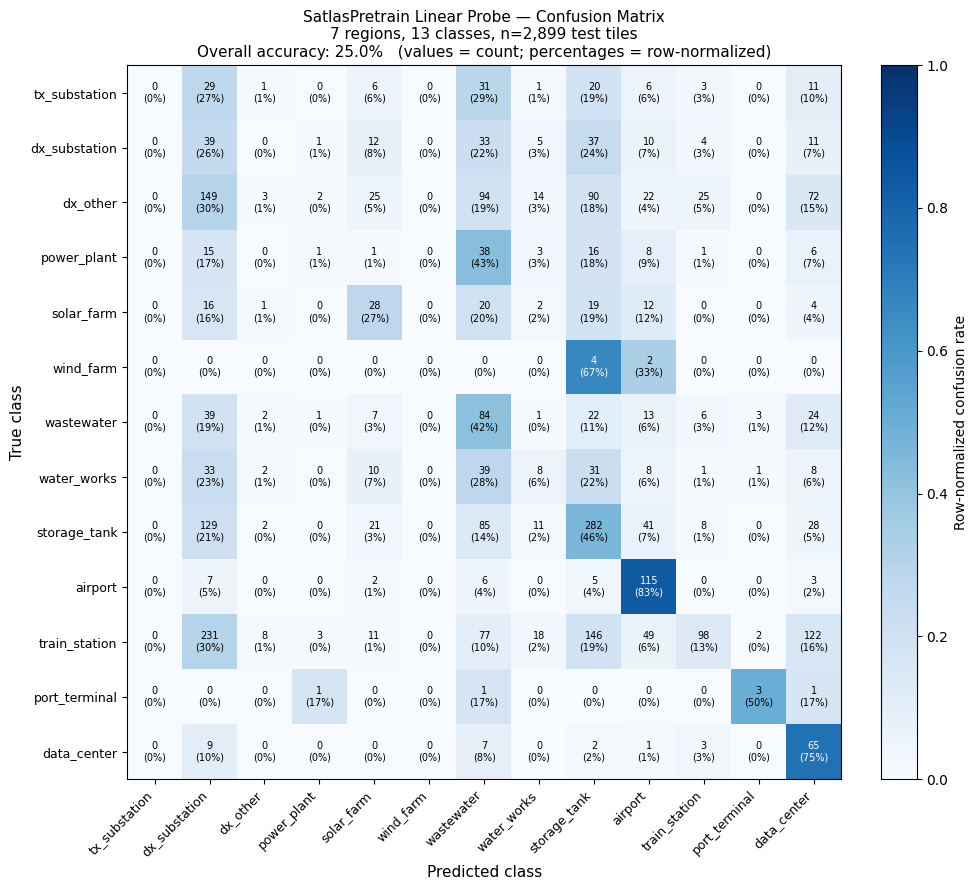

In [11]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Load the 7-region 13-class result
result_path = Path('/content/drive/MyDrive/infra_fm/results/fm_eval_satlas_multisector_v1/satlas_s2_full7region_v1_linear_probe_capped_results.json')

with open(result_path) as f:
    results = json.load(f)

cm = np.array(results['linear_probe']['test']['confusion'])

CLASS_NAMES_SHORT = [
    'tx_substation',
    'dx_substation',
    'dx_other',
    'power_plant',
    'solar_farm',
    'wind_farm',
    'wastewater',
    'water_works',
    'storage_tank',
    'airport',
    'train_station',
    'port_terminal',
    'data_center',
]

# Sanity check
assert len(CLASS_NAMES_SHORT) == 13, f'Expected 13 labels, got {len(CLASS_NAMES_SHORT)}'
assert cm.shape == (13, 13), f'Expected (13,13) matrix, got {cm.shape}'

# Compute overall test accuracy
total_correct = np.trace(cm)
total_predictions = cm.sum()
overall_accuracy = total_correct / total_predictions

# Row-normalize
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

# Plot
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(np.arange(13))
ax.set_yticks(np.arange(13))
ax.set_xticklabels(CLASS_NAMES_SHORT, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(CLASS_NAMES_SHORT, fontsize=9)

# Annotate EVERY cell, including zeros
for i in range(13):
    for j in range(13):
        count = cm[i, j]
        pct = cm_norm[i, j]
        color = 'white' if pct > 0.5 else 'black'
        ax.text(j, i, f'{count}\n({pct*100:.0f}%)',
                ha='center', va='center', fontsize=7, color=color)

ax.set_xlabel('Predicted class', fontsize=11)
ax.set_ylabel('True class', fontsize=11)
ax.set_title(
    f'SatlasPretrain Linear Probe — Confusion Matrix\n'
    f'7 regions, 13 classes, n={int(total_predictions):,} test tiles\n'
    f'Overall accuracy: {overall_accuracy*100:.1f}%   '
    f'(values = count; percentages = row-normalized)',
    fontsize=11
)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Row-normalized confusion rate', fontsize=10)

plt.tight_layout()

out_path = Path('/content/drive/MyDrive/infra_fm/results/fm_eval_satlas_multisector_v1/confusion_matrix_7region_v2.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved to: {out_path}')

# Print accuracy details to console too
print(f'\n=== Accuracy Summary ===')
print(f'Overall accuracy: {total_correct}/{int(total_predictions)} = {overall_accuracy*100:.2f}%')
print(f'\nPer-class accuracy (diagonal):')
for i, name in enumerate(CLASS_NAMES_SHORT):
    row_total = cm[i].sum()
    if row_total == 0:
        print(f'  {name:<14s} (no test samples)')
        continue
    class_acc = cm[i, i] / row_total
    print(f'  {name:<14s} {cm[i,i]:>4d}/{row_total:<4d} = {class_acc*100:5.1f}%')

plt.show()

In [9]:
print(f'CLASS_NAMES_SHORT length: {len(CLASS_NAMES_SHORT)}')
print(f'Confusion matrix shape: {cm.shape}')
print(f'X-axis tick count: {len(ax.get_xticklabels())}')
print(f'Y-axis tick count: {len(ax.get_yticklabels())}')

CLASS_NAMES_SHORT length: 13
Confusion matrix shape: (13, 13)
X-axis tick count: 13
Y-axis tick count: 13


### best checkpoint analysis

In [15]:
# Force CPU loading before instantiating
import torch
original_load = torch.load
def cpu_load(*args, **kwargs):
    kwargs['map_location'] = torch.device('cpu')
    return original_load(*args, **kwargs)
torch.load = cpu_load

# Now try the backbone load
backbone = SatlasS2Backbone(in_channels=7, freeze=True)
model = InfraBenchClassifier(backbone, num_classes=len(CLASS_NAMES))  # don't .to(DEVICE) yet

# Restore torch.load
torch.load = original_load

# Move to CPU device
DEVICE = torch.device('cpu')
model = model.to(DEVICE)

  Adapted first conv: 9 -> 7 channels at "backbone.backbone.features.0.0"


In [16]:
import torch
from pathlib import Path
from torch.utils.data import DataLoader

# Load best-val checkpoint from the S2 7-region run
ckpt_path = Path('/content/drive/MyDrive/infra_fm/results/fm_eval_satlas_multisector_v1/satlas_s2_full7region_v1_linear_probe_capped/checkpoint_best.pt')
print(f'Using checkpoint: {ckpt_path}')
print(f'Exists: {ckpt_path.exists()}')

# Build S2 model
backbone = SatlasS2Backbone(in_channels=7, freeze=True)  # verify the signature matches
model = InfraBenchClassifier(backbone, num_classes=len(CLASS_NAMES)).to(DEVICE)

ckpt = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print(f'\nLoaded checkpoint:')
print(f'  Epoch: {ckpt["epoch"]}')
print(f'  Val macro F1: {ckpt["val_macro_f1"]:.4f}')

# IMPORTANT: this needs to use the S2-wrapped test loader (band_indices='0,1,2,3,4,5,6')
# If you're in the S1 notebook, test_global is currently S1-wrapped (2 channels)
# You'd need to either:
#   - Switch to the S2 notebook and run the eval there
#   - Or rebuild the S2-wrapped datasets in the current runtime

test_loader = DataLoader(
    test_global_s2,  # or whatever the S2-wrapped test set is
    batch_size=16, shuffle=False, num_workers=2, 
    collate_fn=collate, pin_memory=True
)

# Run evaluation
test_result = evaluate(model, test_loader, return_breakdowns=True)

# Print results
print(f'\n=== S2 Best-Checkpoint Test Results (FAIR COMPARISON) ===')
print(f'Test macro F1: {test_result["macro_f1"]:.4f}')
print(f'Test accuracy: {test_result["acc"]:.4f}')
# ... per-class, per-sector, per-region breakdown

Using checkpoint: /content/drive/MyDrive/infra_fm/results/fm_eval_satlas_multisector_v1/satlas_s2_full7region_v1_linear_probe_capped/checkpoint_best.pt
Exists: True


RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.